# Multiple Linear Regression - Complete Practice Notebook

**What is Multiple Linear Regression?**

Multiple Linear Regression (MLR) extends Simple Linear Regression to
**two or more independent variables (X1, X2, ... Xn)** predicting one
dependent variable (Y).

**Equation:**

Y = b0 + b1*X1 + b2*X2 + ... + bn*Xn

- Y    → Predicted value (dependent variable)
- X1..Xn → Independent variables (features)
- b0   → Intercept
- b1..bn → Coefficients (effect of each feature on Y, holding others constant)

**Key Difference from Simple Linear Regression:**
Instead of one straight line, MLR fits a **hyperplane** through
multi-dimensional space. The core idea (minimizing squared errors) stays
the same — just extended to more dimensions.

**New concept this notebook introduces:** datasets often have categorical
(text) columns. Models only understand numbers, so categorical columns
need to be converted using **One-Hot Encoding** before fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Dataset

**Dataset:** 50_Startups.csv
**Source:** Kaggle - 50 Startups Dataset
https://www.kaggle.com/datasets/farhanmd29/50-startups

**Columns:**
- R&D Spend, Administration, Marketing Spend → Numeric features
- State → Categorical feature (New York / California / Florida)
- Profit → Target variable (what we want to predict)

Upload the CSV file manually below (Colab file upload).

In [5]:
df = pd.read_csv('/content/50_Startups[1].csv')
print(df.head())
print('\n',df.shape)
print('\n',df.info())

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

 (50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB

 None


## 1. One-Hot Encoding (Brief Intro)

The "State" column is text, not numbers — models can't use it as-is.

**One-Hot Encoding** converts each category into its own binary (0/1)
column. For example, "State" with 3 categories becomes 2 columns
(we drop one to avoid redundancy — this is called the "dummy variable trap").

**Why drop one column?**
If you know a startup is NOT in California and NOT in Florida, it must be
in New York. So one column is always redundant — keeping it would
introduce perfect multicollinearity.

In [6]:
print("Unique categories in State column:")
print(df["State"].unique())

# pd.get_dummies handles one-hot encoding directly
df_encoded = pd.get_dummies(df, columns=["State"], drop_first=True)

print("\nDataset after One-Hot Encoding:")
print(df_encoded.head())

Unique categories in State column:
['New York' 'California' 'Florida']

Dataset after One-Hot Encoding:
   R&D Spend  Administration  Marketing Spend     Profit  State_Florida  \
0  165349.20       136897.80        471784.10  192261.83          False   
1  162597.70       151377.59        443898.53  191792.06          False   
2  153441.51       101145.55        407934.54  191050.39           True   
3  144372.41       118671.85        383199.62  182901.99          False   
4  142107.34        91391.77        366168.42  166187.94           True   

   State_New York  
0            True  
1           False  
2           False  
3            True  
4           False  


## 2. Defining Features (X) and Target (Y)

In [7]:
X = df_encoded.drop("Profit", axis=1)
Y = df_encoded["Profit"]

print("Features (X):")
print(X.head())
print(f"\nTarget (Y): Profit")
print(Y.head())

Features (X):
   R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
0  165349.20       136897.80        471784.10          False            True
1  162597.70       151377.59        443898.53          False           False
2  153441.51       101145.55        407934.54           True           False
3  144372.41       118671.85        383199.62          False            True
4  142107.34        91391.77        366168.42           True           False

Target (Y): Profit
0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


## 3. Quick Correlation Check

Before fitting, it's good practice to check how strongly each numeric
feature correlates with the target — this builds on what you already know
from the Correlation notebook.

                 R&D Spend  Administration  Marketing Spend  Profit
R&D Spend             1.00            0.24             0.72    0.97
Administration        0.24            1.00            -0.03    0.20
Marketing Spend       0.72           -0.03             1.00    0.75
Profit                0.97            0.20             0.75    1.00


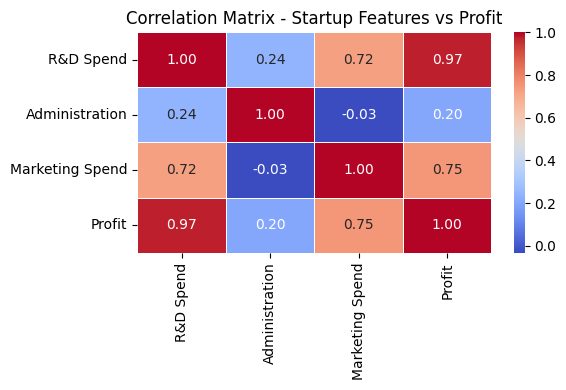

In [8]:
corr_matrix = df[["R&D Spend", "Administration", "Marketing Spend", "Profit"]].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Startup Features vs Profit")
plt.tight_layout()
plt.show()

## 4. Fitting Multiple Linear Regression with Scikit-learn

Note: Unlike Simple Linear Regression, manually solving MLR coefficients
requires matrix algebra (the Normal Equation: b = (XᵀX)⁻¹XᵀY). This is
mathematically heavier and not worth hand-calculating here — sklearn
handles it directly using the same underlying math.

In [9]:
model = LinearRegression()
model.fit(X, Y)

print("Intercept (b0):", model.intercept_)
print("\nCoefficients (b1, b2, ...):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:25s} : {coef:.4f}")

Intercept (b0): 50125.343831604216

Coefficients (b1, b2, ...):
  R&D Spend                 : 0.8060
  Administration            : -0.0270
  Marketing Spend           : 0.0270
  State_Florida             : 198.7888
  State_New York            : -41.8870


## 5. Interpreting Coefficients

Each coefficient tells you how much Profit changes for a 1-unit increase
in that feature, **holding all other features constant**.

For example, a high coefficient on "R&D Spend" means R&D investment has
a strong positive effect on Profit — more so than Administration or
Marketing Spend (you'll see this clearly once you print the values above).

## 6. Making Predictions

In [10]:
df_encoded["Predicted_Profit"] = model.predict(X)
print(df_encoded[["Profit", "Predicted_Profit"]].head(10))

# Predict for a new, unseen startup
# Format: [R&D Spend, Administration, Marketing Spend, State_Florida, State_New York]
new_startup = [[160000, 130000, 300000, 0, 1]]  # hypothetical startup in New York
predicted_profit = model.predict(new_startup)
print(f"\nPredicted Profit for new startup: {predicted_profit[0]:.2f}")

      Profit  Predicted_Profit
0  192261.83     192390.571363
1  191792.06     189071.320105
2  191050.39     182276.186733
3  182901.99     173584.976190
4  166187.94     172277.133817
5  156991.12     163473.807118
6  156122.51     158099.292784
7  155752.60     160155.644649
8  152211.77     151634.743326
9  149759.96     154829.662527

Predicted Profit for new startup: 183630.55


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 7. Visualization - Actual vs Predicted

With multiple features, we can't plot a single best-fit line like in
Simple Linear Regression (it's now a hyperplane in multi-dimensional
space). Instead, the standard way to visualize MLR performance is an
**Actual vs Predicted** scatter plot — a perfect model would show all
points falling exactly on the diagonal line.

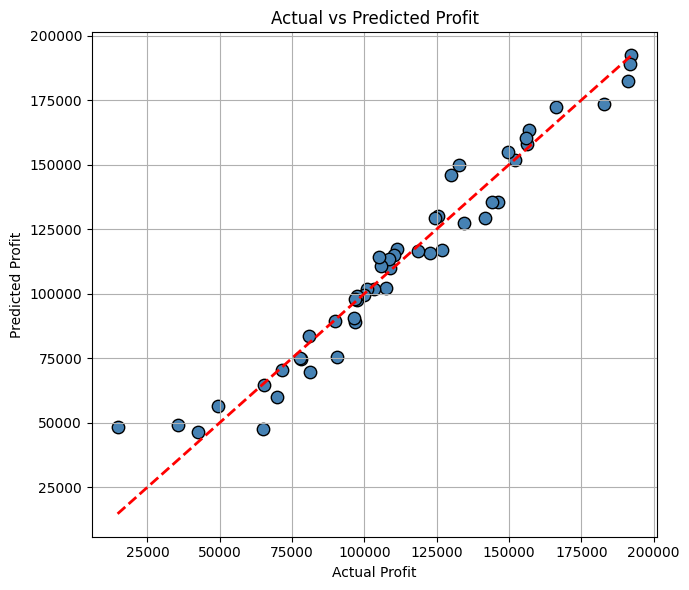

In [11]:
plt.figure(figsize=(7, 6))

plt.scatter(df_encoded["Profit"], df_encoded["Predicted_Profit"],
            color="steelblue", edgecolor="black", s=80)

# Diagonal reference line (perfect prediction line)
min_val = min(df_encoded["Profit"].min(), df_encoded["Predicted_Profit"].min())
max_val = max(df_encoded["Profit"].max(), df_encoded["Predicted_Profit"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, linestyle="--")

plt.title("Actual vs Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- What is Multiple Linear Regression and how it extends Simple Linear Regression
- Handling a categorical column using One-Hot Encoding (and the dummy variable trap)
- Quick correlation check before modeling
- Fitting MLR with Scikit-learn (multiple numeric + encoded features)
- Interpreting coefficients (effect of each feature, holding others constant)
- Making predictions on new, unseen data
- Visualizing performance using Actual vs Predicted plot (since a single
  best-fit line isn't possible with multiple features)

**Note:** Model evaluation metrics (R², MSE, RMSE) are still saved for the
dedicated `04_Model_Evaluation` notebook, as planned.

Copy each cell into Colab, run in order, save as
`Multiple_Linear_Regression.ipynb`, and upload to
`03_Machine_Learning/01_Regression/`.